<h1>Replicate the structure of ViT according to the paper

In [ ]:
import torch
import numpy as np
import requests
import zipfile
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import os
from torchvision.datasets import ImageFolder
from torch.utils.tensorboard import SummaryWriter
import torchvision.models
!pip install torchinfo
from torchinfo import summary
from datetime import date
from tqdm.auto import tqdm
import tarfile

In [ ]:
CLASSES = None

<h2>Data Preparation

In [ ]:
import tarfile
from pathlib import Path

current_path = Path(".")
#Downloads the data
if not((current_path / "cifar-10-python.tar.gz").is_file()):
  print("Downloading cifar-10 data ...")
  with open("./cifar-10-python.tar.gz", 'wb') as f:
    response = requests.get("https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz")
    f.write(response.content)

#Extracts the data
data_path = Path('data')
with tarfile.open(current_path / "cifar-10-python.tar.gz", "r:gz") as tar:
  if not(data_path.is_dir()):
    print("Extracting cifar-10-python.tar.gz into data directory ...")
    data_path.mkdir()
    tar.extractall(data_path)
    print("Finished extracting, removing the compressed file ...")
    os.remove(current_path / "cifar-10-python.tar.gz")

#unpack the data
import pickle
def unpickle(file):
  with open(file, 'rb') as fo:
    dict = pickle.load(fo, encoding='bytes')
  return dict

#print out information about each data batch
data_batch_1 = unpickle("/content/data/cifar-10-batches-py/data_batch_1")
print(f'Each batch dict contains the following keys: {data_batch_1.keys()}')
print(f'bactch_label: {data_batch_1[b'batch_label']}')
print(f'labels is a list of length {len(data_batch_1[b'labels'])}')
print(f'data is a numpy array of shape {data_batch_1[b'data'].shape}, where each row is an image of 32x32x3')
print(f'filenames is a list of corresponding file names for the images e.g. {data_batch_1[b'filenames'][0]}')

Extracting cifar-10-python.tar.gz into data directory ...


/tmp/ipykernel_6503/2483421035.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(data_path)


Finished extracting, removing the compressed file ...
Each batch dict contains the following keys: dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
bactch_label: b'training batch 1 of 5'
labels is a list of length 10000
data is a numpy array of shape (10000, 3072), where each row is an image of 32x32x3
filenames is a list of corresponding file names for the images e.g. b'leptodactylus_pentadactylus_s_000004.png'


In [ ]:
class CustomDataset(torch.utils.data.Dataset):
  def __init__(self, data_file_path, metadata_file_path, transform=None, target_transform=None):
    super().__init__()
    self.data_file = data_file_path
    self.data = unpickle(data_file_path)
    global CLASSES
    CLASSES = self.classes = [x.decode('utf-8') for x in unpickle(metadata_file_path)[b'label_names']] if CLASSES is None else CLASSES #caches the class list
    self.class_to_idx = {name: i for i, name in enumerate(self.classes)}
    self.transform = transform
    self.target_transform = target_transform

  def __len__(self):
    return len(self.data[b'labels'])

  def __getitem__(self, i):
    target = self.data[b'labels'][i]
    img = self.data[b'data'][i].reshape(3, 32, 32).transpose(1,2,0)
    if self.transform:
      img = self.transform(img)
    if self.target_transform:
      target = self.target_transform(target)
    return img, target

In [ ]:
def create_dataloaders(transform):
  #concatenate data batch 1 to 5 into a dataset for training
  train_datasets = [CustomDataset(f"/content/data/cifar-10-batches-py/data_batch_{i}", "/content/data/cifar-10-batches-py/batches.meta", transform=transform) for i in range(1, 6)]
  train_dataset = torch.utils.data.ConcatDataset(train_datasets)

  test_dataset = CustomDataset("/content/data/cifar-10-batches-py/test_batch", "/content/data/cifar-10-batches-py/batches.meta", transform=transform)

  #create DataLoader
  train_dataloader = DataLoader(
      dataset=train_dataset,
      batch_size=32,
      shuffle=True,
      num_workers=os.cpu_count()
  )

  test_dataloader = DataLoader(
      dataset=test_dataset,
      batch_size=32,
      shuffle=True,
      num_workers=os.cpu_count()
  )

  return train_dataloader, test_dataloader

In [ ]:
train_dataloader, test_dataloader = create_dataloaders(transforms.ToTensor())

In [ ]:
next(iter(train_dataloader))[0].shape

torch.Size([32, 3, 32, 32])

In [ ]:
CLASSES

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

<h2>Create Custom ViT model

In [ ]:
class CustomViT(torch.nn.Module):
  #only takes [B, C, H, W] where H = W
  def __init__(self, embed_dim, patch_size, input_size, num_heads, mlp_hidden_dim, output_shape):
    super().__init__()

    #initialize the variables into notations
    self.k = num_heads
    self.D = embed_dim
    self.p = patch_size
    self.H = self.W = input_size
    self.N = int(self.H * self.W / (self.p * self.p) + 1) #number of toekns
    self.mlp_hidden_dim = mlp_hidden_dim

    self.cls = torch.nn.Parameter(torch.randn(1, 1, self.D))

    #Step 1: Split into patches, Linear projection, add CLASS token, Positonal Encoding
    self.conv = torch.nn.Conv2d(in_channels=3, out_channels=self.D, kernel_size=self.p, stride=self.p, padding=0)
    self.flat_2_3 = torch.nn.Flatten(2, 3)
    self.pos = torch.nn.Parameter(torch.randn(1, self.N, self.D))

    #Step 2: transformer encoders
    self.GeLU = torch.nn.GELU()
    self.dropout = torch.nn.Dropout(p=0.1)

    #Layer 1
    self.msp_ln_1 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_1 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_1 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_1 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 2
    self.msp_ln_2 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_2 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_2 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_2 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 3
    self.msp_ln_3 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_3 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_3 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_3 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 4
    self.msp_ln_4 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_4 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_4 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_4 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Step 3: Classifier
    self.classifier_LN = torch.nn.LayerNorm([self.D])
    self.classifier = torch.nn.Linear(self.D, output_shape)

  def forward(self, x):
    batch_size = x.shape[0]
    #Step 1: turns an image to patch embeddings
    z = self.flat_2_3(self.conv(x)).permute(0, 2, 1) #[32, 3, 32, 32] -> [32, 16, 64]
    z = torch.concatenate(tensors=(self.cls.expand(batch_size, -1, -1), z), dim=1) #adding class token ->[32, 17, 64]
    z = z + self.pos
    z = self.dropout(z)

    #Step 2: feed patch embeddings into transformer encoder
    z = self.msp_ln_1(z)
    z, self.a1 = self.msp_1(z,z,z)
    z = self.mlp_ln_1(z)
    z = self.mlp_1(z)

    z = self.msp_ln_2(z)
    z, self.a2 = self.msp_2(z,z,z)
    z = self.mlp_ln_2(z)
    z = self.mlp_2(z)

    z = self.msp_ln_3(z)
    z, self.a3 = self.msp_3(z,z,z)
    z = self.mlp_ln_3(z)
    z = self.mlp_3(z)

    z = self.msp_ln_4(z)
    z, self.a4 = self.msp_4(z,z,z)
    z = self.mlp_ln_4(z)
    z = self.mlp_4(z)

    #Step 3: Classifier
    z0 = z[:, 0, :].squeeze(1) #[32, 64]
    logits = self.classifier(self.classifier_LN(z0))

    return logits


In [ ]:
class CustomViTV2(torch.nn.Module):
  #only takes [B, C, H, W] where H = W
  def __init__(self, embed_dim, patch_size, input_size, num_heads, mlp_hidden_dim, output_shape):
    super().__init__()

    #initialize the variables into notations
    self.k = num_heads
    self.D = embed_dim
    self.p = patch_size
    self.H = self.W = input_size
    self.N = int(self.H * self.W / (self.p * self.p) + 1) #number of toekns
    self.mlp_hidden_dim = mlp_hidden_dim
    self.attention_matrix = None

    self.cls = torch.nn.Parameter(torch.randn(1, 1, self.D))

    #Step 1: Split into patches, Linear projection, add CLASS token, Positonal Encoding
    self.conv = torch.nn.Conv2d(in_channels=3, out_channels=self.D, kernel_size=self.p, stride=self.p, padding=0)
    self.flat_2_3 = torch.nn.Flatten(2, 3)
    self.pos = torch.nn.Parameter(torch.randn(1, self.N, self.D))

    #Step 2: transformer encoders
    self.GeLU = torch.nn.GELU()
    self.dropout = torch.nn.Dropout(p=0.1)

    #Layer 1
    self.msp_ln_1 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_1 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_1 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_1 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 2
    self.msp_ln_2 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_2 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_2 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_2 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 3
    self.msp_ln_3 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_3 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_3 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_3 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Layer 4
    self.msp_ln_4 = torch.nn.LayerNorm([self.N, self.D])
    self.msp_4 = torch.nn.MultiheadAttention(self.D, self.k, batch_first=True)
    self.mlp_ln_4 = torch.nn.LayerNorm([self.N, self.D])
    self.mlp_4 = torch.nn.Sequential(
        torch.nn.Linear(self.D, self.mlp_hidden_dim),
        self.GeLU,
        self.dropout,
        torch.nn.Linear(self.mlp_hidden_dim, self.D),
        self.dropout
    )

    #Step 3: Classifier
    self.classifier_LN = torch.nn.LayerNorm([self.D])
    self.classifier = torch.nn.Linear(self.D, output_shape)

  def forward(self, x):
    batch_size = x.shape[0]
    #Step 1: turns an image to patch embeddings
    z = self.flat_2_3(self.conv(x)).permute(0, 2, 1) #[32, 3, 32, 32] -> [32, 16, 64]
    z = torch.concatenate(tensors=(self.cls.expand(batch_size, -1, -1), z), dim=1) #adding class token ->[32, 17, 64]
    z = z + self.pos
    z = self.dropout(z)

    #Step 2: feed patch embeddings into transformer encoder
    # Layer 1
    z = z + self.msp_1(self.msp_ln_1(z), self.msp_ln_1(z), self.msp_ln_1(z))[0]
    z = z + self.mlp_1(self.mlp_ln_1(z))

    # Layer 2
    z = z + self.msp_2(self.msp_ln_2(z), self.msp_ln_2(z), self.msp_ln_2(z))[0]
    z = z + self.mlp_2(self.mlp_ln_2(z))

    # Layer 3
    z = z + self.msp_3(self.msp_ln_3(z), self.msp_ln_3(z), self.msp_ln_3(z))[0]
    z = z + self.mlp_3(self.mlp_ln_3(z))

    # Layer 4
    z = z + self.msp_4(self.msp_ln_4(z), self.msp_ln_4(z), self.msp_ln_4(z))[0]
    z = z + self.mlp_4(self.mlp_ln_4(z))

    #Step 3: Classifier
    z0 = z[:, 0, :].squeeze(1) #[32, 64]
    logits = self.classifier(self.classifier_LN(z0))

    return logits


The initial approach will be spliting the patches of 8x8 (N=16, D=64) then feed it into 4 layers of transformer encoder with 4 heads followed by a linear classifier

<h2>create a training loop

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               current_epoch: int):
    model.train()
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate accuracy
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device,
          d: int = 1):
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    model.to(device=device)

    # Training Loop
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device,
                                          current_epoch=epoch)
        #report progress and test on every d epoch
        if epoch % d == 0:
          test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device)

          print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
          )

          # Update results
          results["train_loss"].append(train_loss)
          results["train_acc"].append(train_acc)
          results["test_loss"].append(test_loss)
          results["test_acc"].append(test_acc)
    return results

In [ ]:
model_0 = CustomViT(embed_dim=64, patch_size=8, input_size=32, num_heads=4, mlp_hidden_dim=256, output_shape=len(CLASSES))

In [ ]:
results = train(model_0, train_dataloader, test_dataloader, torch.nn.CrossEntropyLoss(), torch.optim.SGD(params=model_0.parameters(), lr=0.01), 10, torch.device("cuda"))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.1177 | train_acc: 0.2016 | test_loss: 1.9642 | test_acc: 0.2630
Epoch: 2 | train_loss: 1.9696 | train_acc: 0.2718 | test_loss: 1.9183 | test_acc: 0.2969
Epoch: 3 | train_loss: 1.8853 | train_acc: 0.3101 | test_loss: 1.8285 | test_acc: 0.3355
Epoch: 4 | train_loss: 1.8191 | train_acc: 0.3397 | test_loss: 1.7173 | test_acc: 0.3803
Epoch: 5 | train_loss: 1.7616 | train_acc: 0.3611 | test_loss: 1.6742 | test_acc: 0.3881
Epoch: 6 | train_loss: 1.7161 | train_acc: 0.3786 | test_loss: 1.6805 | test_acc: 0.3935
Epoch: 7 | train_loss: 1.6851 | train_acc: 0.3902 | test_loss: 1.6273 | test_acc: 0.4142
Epoch: 8 | train_loss: 1.6497 | train_acc: 0.4020 | test_loss: 1.5930 | test_acc: 0.4237
Epoch: 9 | train_loss: 1.6220 | train_acc: 0.4122 | test_loss: 1.5583 | test_acc: 0.4406
Epoch: 10 | train_loss: 1.5985 | train_acc: 0.4243 | test_loss: 1.5253 | test_acc: 0.4532


In [ ]:
model_1 = CustomViTV2(embed_dim=64, patch_size=8, input_size=32, num_heads=4, mlp_hidden_dim=256, output_shape=len(CLASSES))

In [ ]:
results1 = train(model_1, train_dataloader, test_dataloader, torch.nn.CrossEntropyLoss(), torch.optim.SGD(params=model_1.parameters(), lr=0.01), 10, torch.device("cuda"))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2063 | train_acc: 0.1598 | test_loss: 2.0905 | test_acc: 0.2038
Epoch: 2 | train_loss: 2.0514 | train_acc: 0.2281 | test_loss: 1.9373 | test_acc: 0.2867
Epoch: 3 | train_loss: 1.9301 | train_acc: 0.2875 | test_loss: 1.8471 | test_acc: 0.3242
Epoch: 4 | train_loss: 1.8487 | train_acc: 0.3276 | test_loss: 1.7702 | test_acc: 0.3574
Epoch: 5 | train_loss: 1.7904 | train_acc: 0.3530 | test_loss: 1.7018 | test_acc: 0.3963
Epoch: 6 | train_loss: 1.7305 | train_acc: 0.3801 | test_loss: 1.6681 | test_acc: 0.4046
Epoch: 7 | train_loss: 1.6827 | train_acc: 0.3986 | test_loss: 1.6247 | test_acc: 0.4202
Epoch: 8 | train_loss: 1.6424 | train_acc: 0.4114 | test_loss: 1.5678 | test_acc: 0.4400
Epoch: 9 | train_loss: 1.6046 | train_acc: 0.4264 | test_loss: 1.5600 | test_acc: 0.4381
Epoch: 10 | train_loss: 1.5769 | train_acc: 0.4333 | test_loss: 1.5226 | test_acc: 0.4508


In [ ]:
def plot_metrics(train_loss, test_loss, train_acc, test_acc):
  epochs = range(1, len(train_loss)+1)
  fig, ax = plt.subplots(1,2)
  ax[0].plot(epochs, train_loss, label='train', c='r')
  ax[0].plot(epochs, test_loss, label='test', c='b')
  ax[0].legend()
  ax[0].set_title("Cross Entropy Loss")
  ax[1].plot(epochs, train_acc, label='train', c='r')
  ax[1].plot(epochs, test_acc, label='test', c='b')
  ax[1].legend()
  ax[1].set_title("Accuracy")


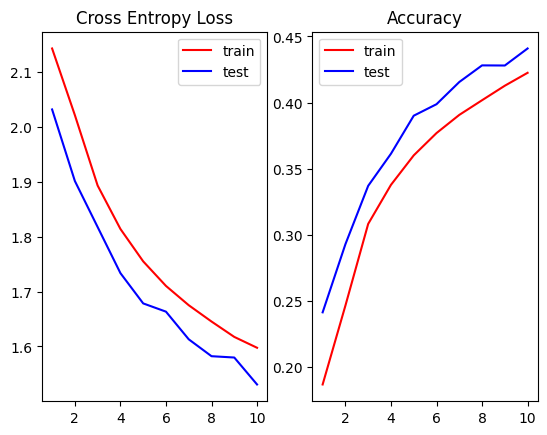

In [ ]:
plot_metrics(**results)

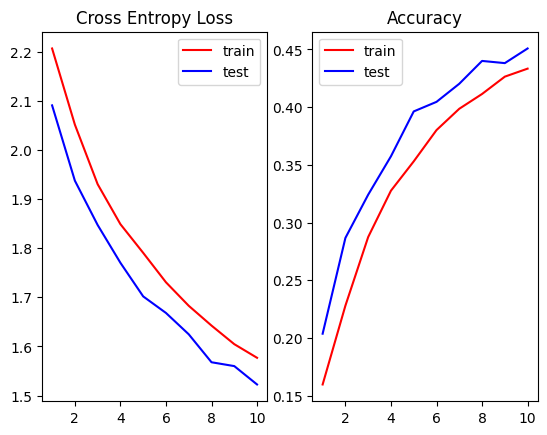

In [ ]:
plot_metrics(**results1)

both versions seem to grasp onto the data really well and still learning until the 10th epoch. Ill try to train more epochs and see what happens

In [ ]:
model_2 = CustomViTV2(embed_dim=64, patch_size=8, input_size=32, num_heads=4, mlp_hidden_dim=256, output_shape=len(CLASSES))

In [ ]:
results2 = train(model_2, train_dataloader, test_dataloader, torch.nn.CrossEntropyLoss(), torch.optim.SGD(params=model_2.parameters(), lr=0.01), 100, torch.device("cuda"), d=5)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.2485 | train_acc: 0.1451 | test_loss: 2.0955 | test_acc: 0.2016
Epoch: 6 | train_loss: 1.7969 | train_acc: 0.3531 | test_loss: 1.7330 | test_acc: 0.3816
Epoch: 11 | train_loss: 1.5869 | train_acc: 0.4303 | test_loss: 1.5192 | test_acc: 0.4560
Epoch: 16 | train_loss: 1.4871 | train_acc: 0.4656 | test_loss: 1.4291 | test_acc: 0.4887
Epoch: 21 | train_loss: 1.4125 | train_acc: 0.4932 | test_loss: 1.3998 | test_acc: 0.5001
Epoch: 26 | train_loss: 1.3496 | train_acc: 0.5149 | test_loss: 1.3282 | test_acc: 0.5292
Epoch: 31 | train_loss: 1.2961 | train_acc: 0.5324 | test_loss: 1.2892 | test_acc: 0.5414
Epoch: 36 | train_loss: 1.2529 | train_acc: 0.5463 | test_loss: 1.2805 | test_acc: 0.5482
Epoch: 41 | train_loss: 1.2158 | train_acc: 0.5635 | test_loss: 1.2466 | test_acc: 0.5566
Epoch: 46 | train_loss: 1.1768 | train_acc: 0.5762 | test_loss: 1.2334 | test_acc: 0.5579
Epoch: 51 | train_loss: 1.1405 | train_acc: 0.5891 | test_loss: 1.2141 | test_acc: 0.5741
Epoch: 56 | 

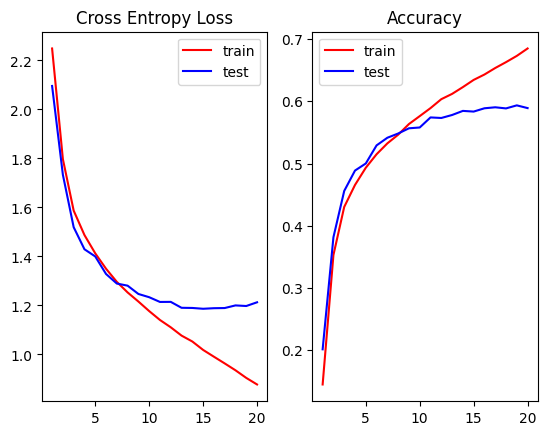

In [ ]:
plot_metrics(**results2)

<h2>Save Model

In [ ]:
torch.save(model_2.state_dict(), 'ViT_model.pth')

In [ ]:
model_3 = CustomViTV2(embed_dim=64, patch_size=8, input_size=32, num_heads=4, mlp_hidden_dim=256, output_shape=len(CLASSES))

In [ ]:
model_3.load_state_dict(torch.load('ViT_model.pth'))

<All keys matched successfully>

In [ ]:
model_3.eval()
model_3()

<h2>Test inference

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
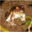

In [ ]:
data_batch_1[b'data'][0].reshape(3, 32, 32).transpose(1,2,0)

In [ ]:
img = transforms.ToTensor()(data_batch_1[b'data'][0].reshape(3, 32, 32).transpose(1,2,0))
CLASSES[torch.argmax(model_3(img.expand(1, -1, -1, -1)))]

'frog'

In [ ]:
CLASSES[data_batch_1[b'labels'][0]]

'frog'

<h2>Examine the attention of the CLS token on each pixel

In [ ]:
def show_attention(img):
  #img = transforms.ToTensor()(data_batch_1[b'data'][0].reshape(3, 32, 32).transpose(1,2,0)).expand(1, -1, -1, -1).to(device='cuda')
  model_0.eval()
  cls = model_0(img)

  t1 = model_0.a1[0, 0, 1:]
  t2 = model_0.a2[0, 0, 1:]
  t3 = model_0.a3[0, 0, 1:]

  attn_map = torch.mean(torch.stack([t1, t2, t3]), dim=0).squeeze().resize(4,4)

  # Upsample to original image size
  attn_map = F.interpolate(
      attn_map.unsqueeze(0).unsqueeze(0),
      size=(32, 32),
      mode='bilinear',
      align_corners=False
  ).squeeze().cpu().detach().numpy()

  # Normalize to [0, 1]
  attn_map = 1.2 - (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8) #higher attention lower value -> lower alpha higher transparency

  overlay = np.zeros(shape=(32, 32, 4)) #black overlay
  overlay[:, :, 3] = attn_map #set transparency proportional to attention

  # Prepare original image
  img = img.squeeze(0)
  orig = img.permute(1, 2, 0).cpu().numpy()
  if orig.max() > 1.0:
      orig = orig / 255.0

  plt.imshow(img.permute(1,2,0).cpu().detach().numpy())
  plt.imshow(overlay)
  plt.title(cls)
  plt.show()

/tmp/ipykernel_6503/1407935362.py:2: UserWarning: non-inplace resize is deprecated
  attn_map = torch.mean(torch.stack([t1, t2, t3]), dim=0).squeeze().resize(4,4)


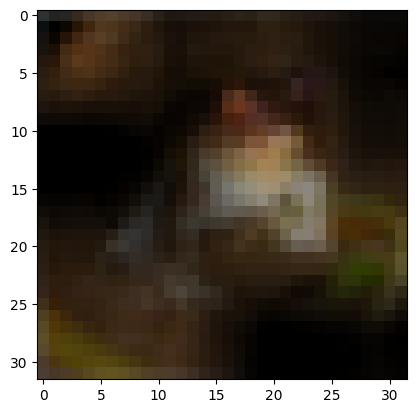

In [ ]:
import torch.nn.functional as F
img = transforms.ToTensor()(data_batch_1[b'data'][0].reshape(3, 32, 32).transpose(1,2,0)).expand(1, -1, -1, -1).to(device='cuda')
show_attention(img)